In [15]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/Clean Data')
print(os.listdir())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['df_crashes.csv']


In [16]:
import pandas as pd
df_crashes=pd.read_csv("df_crashes.csv")

In [17]:
import pandas as pd

df = df_crashes.copy()

# --- 1) Make the binary target ---
df["SEVERE_BIN"] = ((df["INJURIES_FATAL"] > 0) | (df["INJURIES_INCAPACITATING"] > 0)).astype(int)

# Quick sanity check on class balance
pos = df["SEVERE_BIN"].sum()
neg = (1 - df["SEVERE_BIN"]).sum()
print(f"Severe=1: {pos:,}  |  Non-severe=0: {neg:,}  |  Pos-rate: {pos/len(df):.4%}")

# --- 2) Drop outcome leakage + identifiers ---
leakage_cols = [
    # direct outcomes / near-outcomes
    "INJURIES_TOTAL","INJURIES_FATAL","INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING","INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION","MOST_SEVERE_INJURY","DAMAGE",
    # timestamps/IDs/free-text not meant for modeling
    "CRASH_RECORD_ID","CRASH_DATE","DATE_POLICE_NOTIFIED",
    "STREET_NO","STREET_NAME"
]

# keep causes for now (they are predictive and available in reports);


X = df.drop(columns=leakage_cols + ["SEVERE_BIN"])
y = df["SEVERE_BIN"]

print("X shape:", X.shape, "| y shape:", y.shape)
X.head().T.head(20)

Severe=1: 15,791  |  Non-severe=0: 933,319  |  Pos-rate: 1.6638%
X shape: (949110, 25) | y shape: (949110,)


,0,1,2,3,4
POSTED_SPEED_LIMIT,30,30,25,25,35
TRAFFIC_CONTROL_DEVICE,TRAFFIC SIGNAL,NO CONTROLS,STOP SIGN/FLASHER,NO CONTROLS,NO CONTROLS
DEVICE_CONDITION,FUNCTIONING PROPERLY,NO CONTROLS,UNKNOWN,NO CONTROLS,NO CONTROLS
WEATHER_CONDITION,RAIN,OTHER,RAIN,CLEAR,CLEAR
LIGHTING_CONDITION,"DARKNESS, LIGHTED ROAD","DARKNESS, LIGHTED ROAD","DARKNESS, LIGHTED ROAD","DARKNESS, LIGHTED ROAD",DARKNESS
FIRST_CRASH_TYPE,REAR TO FRONT,PARKED MOTOR VEHICLE,FIXED OBJECT,PARKED MOTOR VEHICLE,SIDESWIPE SAME DIRECTION
TRAFFICWAY_TYPE,FOUR WAY,NOT DIVIDED,T-INTERSECTION,ONE-WAY,NOT DIVIDED
ALIGNMENT,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL,STRAIGHT AND LEVEL
ROADWAY_SURFACE_COND,WET,OTHER,WET,WET,WET
ROAD_DEFECT,NO DEFECTS,NO DEFECTS,UNKNOWN,NO DEFECTS,NO DEFECTS


In [18]:
# ---Remove BEAT_OF_OCCURRENCE ---
if "BEAT_OF_OCCURRENCE" in X.columns:
    X = X.drop(columns=["BEAT_OF_OCCURRENCE"])

# ---Convert time & region columns to categorical ---
cat_time_cols = ["CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "zipcode"]

# Fill missing zipcodes with a placeholder (string) before converting
X["zipcode"] = X["zipcode"].fillna("unknown").astype(str)

for col in cat_time_cols:
    X[col] = X[col].astype("category")

# ---Double-check categorical summary ---
cat_summary = {col: X[col].nunique() for col in cat_time_cols}
print("Categorical columns:", cat_summary)
print("\nFinal feature count:", X.shape[1])

Categorical columns: {'CRASH_HOUR': 24, 'CRASH_DAY_OF_WEEK': 7, 'CRASH_MONTH': 12, 'zipcode': 60}

Final feature count: 24


In [19]:
# copy
df_model = X.copy()

# -Numeric, binary, and categorical base features ---
numeric_cols = [
    'POSTED_SPEED_LIMIT','NUM_UNITS','LATITUDE','LONGITUDE'
]
binary_cols = ['INTERSECTION_RELATED_I','HIT_AND_RUN_I']
cat_cols = [
    'TRAFFIC_CONTROL_DEVICE','DEVICE_CONDITION','WEATHER_CONDITION','LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE','TRAFFICWAY_TYPE','ALIGNMENT','ROADWAY_SURFACE_COND',
    'ROAD_DEFECT','REPORT_TYPE','CRASH_TYPE','PRIM_CONTRIBUTORY_CAUSE',
    'SEC_CONTRIBUTORY_CAUSE','STREET_DIRECTION','CRASH_HOUR','CRASH_DAY_OF_WEEK',
    'CRASH_MONTH','zipcode'
]

# -Feature engineering ---
# Weekend indicator
df_model['IS_WEEKEND'] = df_model['CRASH_DAY_OF_WEEK'].apply(lambda x: 1 if int(x) >= 6 else 0)

# Nighttime indicator
df_model['IS_NIGHT'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (int(x) <= 6) or (int(x) >= 20) else 0)

# Rush hour indicator
df_model['RUSH_HOUR'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (7 <= int(x) <= 9) or (16 <= int(x) <= 18) else 0)

# Hazardous weather indicator — broad list of risky types
hazardous_weather = [
    'RAIN', 'SNOW', 'FOG/SMOKE/HAZE', 'FREEZING RAIN/DRIZZLE',
    'SLEET/HAIL', 'BLOWING SNOW', 'BLOWING SAND, SOIL, DIRT',
    'SEVERE CROSS WIND GATE'
]
df_model['IS_RAIN_SNOW'] = df_model['WEATHER_CONDITION'].apply(
    lambda w: 1 if str(w).upper() in hazardous_weather else 0
)

# High-speed zone indicator
df_model['HIGH_SPEED_ZONE'] = df_model['POSTED_SPEED_LIMIT'].apply(lambda s: 1 if s >= 40 else 0)

# --- Final engineered feature list ---
engineered_cols = ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW','HIGH_SPEED_ZONE']

# ---Final column groups ---
numeric_cols_final = numeric_cols + ['HIGH_SPEED_ZONE']
binary_cols_final = binary_cols + ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW']
categorical_cols_final = cat_cols

print(f"Numeric columns ({len(numeric_cols_final)}):", numeric_cols_final)
print(f"Binary columns ({len(binary_cols_final)}):", binary_cols_final)
print(f"Categorical columns ({len(categorical_cols_final)}):", categorical_cols_final)
print("\n Total final features:", len(numeric_cols_final) + len(binary_cols_final) + len(categorical_cols_final))
print("DataFrame shape:", df_model.shape)
df_model.head()

Numeric columns (5): ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'LATITUDE', 'LONGITUDE', 'HIGH_SPEED_ZONE']
Binary columns (6): ['INTERSECTION_RELATED_I', 'HIT_AND_RUN_I', 'IS_WEEKEND', 'IS_NIGHT', 'RUSH_HOUR', 'IS_RAIN_SNOW']
Categorical columns (18): ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'zipcode']

 Total final features: 29
DataFrame shape: (949110, 29)


,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,...,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,zipcode,IS_WEEKEND,IS_NIGHT,RUSH_HOUR,IS_RAIN_SNOW,HIGH_SPEED_ZONE
0,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,"DARKNESS, LIGHTED ROAD",REAR TO FRONT,FOUR WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.968643,-87.698492,60625.0,0,1,0,1,0
1,30,NO CONTROLS,NO CONTROLS,OTHER,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,OTHER,NO DEFECTS,...,3,10,41.826667,-87.689679,60632.0,0,1,0,0,0
2,25,STOP SIGN/FLASHER,UNKNOWN,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,T-INTERSECTION,STRAIGHT AND LEVEL,WET,UNKNOWN,...,3,10,41.885533,-87.759074,60644.0,0,1,0,1,0
3,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.823030,-87.621437,60653.0,0,1,0,0,0
4,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,2,10,41.828208,-87.670489,60609.0,0,1,0,0,0


<h1>Using Resampling Technique</h1>

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve
)
import numpy as np

#   1) SPLIT FIRST
# ================================================================
X = df_model.copy()
y = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y     # always stratify for class imbalance
)

print("Original train severe rate:", y_train.mean())
print("Original test severe rate:", y_test.mean())


#   2) UPSAMPLE MINORITY ONLY IN TRAIN SET to 25%
# ================================================================
train_df = X_train.copy()
train_df["label"] = y_train

minor = train_df[train_df["label"] == 1]
major = train_df[train_df["label"] == 0]

print("Train minority:", len(minor))
print("Train majority:", len(major))

# Upsample minority to 25% of majority
target_ratio = 0.25
target_minority_size = int(target_ratio * len(major))

minor_up = resample(
    minor,
    replace=True,
    n_samples=target_minority_size,
    random_state=42
)

# Build balanced training set
train_balanced = pd.concat([major, minor_up]).sample(frac=1, random_state=42)

X_train_bal = train_balanced.drop("label", axis=1)
y_train_bal = train_balanced["label"]

print("Balanced train severe rate:", y_train_bal.mean())
print("Balanced train shape:", X_train_bal.shape)


#   3) Convert categorical columns
# ================================================================
for col in categorical_cols_final:
    X_train_bal[col] = X_train_bal[col].astype("category")
    X_test[col] = X_test[col].astype("category")

cat_features = [c for c in X_train_bal.columns if str(X_train_bal[c].dtype) == "category"]


#   4) Train LightGBM
# ================================================================
lgbm = LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    feature_fraction=0.7,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    class_weight={0: 1, 1: 5},
    n_jobs=-1
)

lgbm.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    categorical_feature=cat_features,
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=100)]
)

# ================================================================
#   5) Evaluate at threshold 0.5
# ================================================================
probs = lgbm.predict_proba(X_test)[:, 1]
pred_05 = (probs >= 0.5).astype(int)

print("\n================ Default Threshold (0.5) ================")
print("Classification Report:\n", classification_report(y_test, pred_05, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_05))

# ================================================================
#   6) Best F2 Threshold
# ================================================================
prec, rec, thresh = precision_recall_curve(y_test, probs)
beta = 2.0

f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
best_idx = np.nanargmax(f2)
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

pred_best = (probs >= best_thresh).astype(int)

print(f"\n================ Best F2 Threshold: {best_thresh:.3f} ================")
print("Classification Report @Best-F2:\n", classification_report(y_test, pred_best, digits=3))
print("Confusion Matrix @Best-F2:\n", confusion_matrix(y_test, pred_best))

Original train severe rate: 0.016637955558365204
Original test severe rate: 0.016636638535048626
Train minority: 12633
Train majority: 746655
Balanced train severe rate: 0.19999935713229575
Balanced train shape: (933318, 29)
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 186663, number of negative: 746655
[Lig

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve
)
import numpy as np
import pandas as pd

# ================================================================
# 0) DATA SPLIT (same for all experiments)
# ================================================================
X = df_model.copy()
y = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original train severe rate:", y_train.mean())
print("Original test severe rate:", y_test.mean())
print("------------------------------------------------------")

# ================================================================
# Function to run experiment for a given resample ratio
# ================================================================
def run_experiment(target_ratio):

    print(f"\n==================== Testing Resample Ratio: {target_ratio*100:.0f}% ====================")

    # -----------------------------------
    # Resample minority
    train_df = X_train.copy()
    train_df["label"] = y_train

    minor = train_df[train_df["label"] == 1]
    major = train_df[train_df["label"] == 0]

    target_minority_size = int(target_ratio * len(major))

    minor_up = resample(
        minor,
        replace=True,
        n_samples=target_minority_size,
        random_state=42
    )

    train_balanced = pd.concat([major, minor_up]).sample(frac=1, random_state=42)

    X_train_bal = train_balanced.drop("label", axis=1)
    y_train_bal = train_balanced["label"]

    print("Balanced train severe rate:", y_train_bal.mean())
    print("Balanced train shape:", X_train_bal.shape)

    # -----------------------------------
    # Convert categoricals
    for col in categorical_cols_final:
        X_train_bal[col] = X_train_bal[col].astype("category")
        X_test[col] = X_test[col].astype("category")

    cat_features = [c for c in X_train_bal.columns if str(X_train_bal[c].dtype) == "category"]

    # -----------------------------------
    # Train LightGBM
    lgbm = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=127,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight={0: 1, 1: 5},
        n_jobs=-1
    )

    lgbm.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        categorical_feature=cat_features,
        callbacks=[early_stopping(stopping_rounds=100)]
    )

    # -----------------------------------
    # Evaluate
    probs = lgbm.predict_proba(X_test)[:, 1]

    # Compute F2 threshold
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    beta = 2.0
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
    best_idx = np.nanargmax(f2)
    best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

    # Predict
    pred_best = (probs >= best_thresh).astype(int)

    # Output results
    print(f"Best F2 Threshold: {best_thresh:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, pred_best, digits=3))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred_best))

    # Return metrics for comparison
    return {
        "ratio": target_ratio,
        "threshold": best_thresh,
        "precision_1": classification_report(y_test, pred_best, output_dict=True)["1"]["precision"],
        "recall_1": classification_report(y_test, pred_best, output_dict=True)["1"]["recall"],
        "f2_1": (5 * classification_report(y_test, pred_best, output_dict=True)["1"]["precision"] *
                    classification_report(y_test, pred_best, output_dict=True)["1"]["recall"]) /
                    (4 * classification_report(y_test, pred_best, output_dict=True)["1"]["precision"] +
                     classification_report(y_test, pred_best, output_dict=True)["1"]["recall"] + 1e-12)
    }

# ================================================================
# 3) RUN EXPERIMENTS FOR MULTIPLE RESAMPLING RATIOS
# ================================================================
ratios = [0.20, 0.25, 0.30]

results = []

for r in ratios:
    res = run_experiment(r)
    results.append(res)

# ================================================================
# 4) PRINT SUMMARY
# ================================================================
print("\n===================== SUMMARY =====================")
for r in results:
    print(f"Ratio={r['ratio']*100:.0f}% | Thresh={r['threshold']:.3f} | Precision={r['precision_1']:.3f} | Recall={r['recall_1']:.3f} | F2={r['f2_1']:.3f}")


Original train severe rate: 0.016637955558365204
Original test severe rate: 0.016636638535048626
------------------------------------------------------

==================== Testing Resample Ratio: 20% ====================
Balanced train severe rate: 0.16666666666666666
Balanced train shape: (895986, 29)
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=

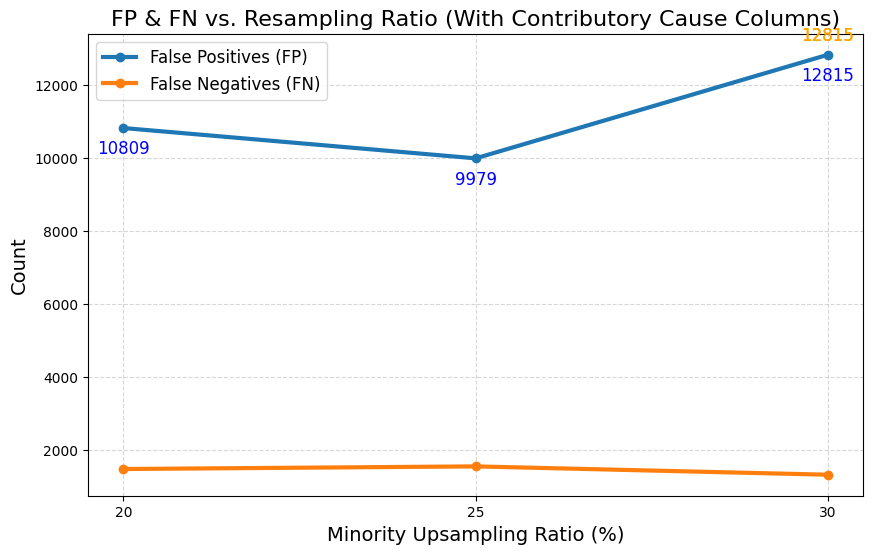

In [22]:
import matplotlib.pyplot as plt

# ---------------------------------------
# Your experiment results (WITH cause columns)
# ---------------------------------------
ratios = [20, 25, 30]   # in percent

FP = [10809, 9979, 12815]
FN = [1477, 1549, 1321]

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(10,6))

# FP line
plt.plot(ratios, FP, marker='o', linewidth=3, label="False Positives (FP)")
for z, k in zip(ratios, FP):
    plt.text(z, k-700, str(k), ha='center', fontsize=12, color='blue')  # FP label

# FN line
plt.plot(ratios, FN, marker='o', linewidth=3, label="False Negatives (FN)")
for x, y in zip(ratios, FN):
    plt.text(z, k+400, str(k), ha='center', fontsize=12, color='orange')  # FN label

plt.title("FP & FN vs. Resampling Ratio (With Contributory Cause Columns)", fontsize=16)
plt.xlabel("Minority Upsampling Ratio (%)", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(ratios)
plt.legend(fontsize=12)

plt.show()


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_cost(probs, y_test, COST_FN, COST_FP=1):
    thresholds = np.linspace(0.01, 0.99, 200)

    best_cost = float("inf")
    best_t = None
    best_stats = None

    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        cost = COST_FN * fn + COST_FP * fp

        if cost < best_cost:
            best_cost = cost
            best_t = t
            best_stats = (tn, fp, fn, tp)

    tn, fp, fn, tp = best_stats

    print("\n====================================================")
    print(f"  COST_FN = {COST_FN}  |  COST_FP = {COST_FP}")
    print("====================================================")
    print(f"Best Threshold: {best_t:.3f}")
    print(f"Minimum Cost: {best_cost:,}")
    print(f"Confusion Matrix:")
    print(f"TN={tn:,}   FP={fp:,}")
    print(f"FN={fn:,}   TP={tp:,}")

    pred = (probs >= best_t).astype(int)
    print("\nClassification Report:\n")
    print(classification_report(y_test, pred, digits=3))

    print("----------------------------------------------------")
    print(f"FN: {fn:,}   | FP: {fp:,}")
    print(f"Total Cost = FN*{COST_FN} + FP*1 = {best_cost:,}")
    print("====================================================\n")

    return {
        "threshold": best_t,
        "cost": best_cost,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }


# ---------------------------------------------------------
# Run all cost levels
# ---------------------------------------------------------
results_10 = evaluate_cost(probs, y_test, COST_FN=10)
results_20 = evaluate_cost(probs, y_test, COST_FN=20)
results_50 = evaluate_cost(probs, y_test, COST_FN=50)



  COST_FN = 10  |  COST_FP = 1
Best Threshold: 0.837
Minimum Cost: 25,258
Confusion Matrix:
TN=178,516   FP=8,148
FN=1,711   TP=1,447

Classification Report:

              precision    recall  f1-score   support

           0      0.991     0.956     0.973    186664
           1      0.151     0.458     0.227      3158

    accuracy                          0.948    189822
   macro avg      0.571     0.707     0.600    189822
weighted avg      0.977     0.948     0.961    189822

----------------------------------------------------
FN: 1,711   | FP: 8,148
Total Cost = FN*10 + FP*1 = 25,258


  COST_FN = 20  |  COST_FP = 1
Best Threshold: 0.690
Minimum Cost: 38,038
Confusion Matrix:
TN=161,906   FP=24,758
FN=664   TP=2,494

Classification Report:

              precision    recall  f1-score   support

           0      0.996     0.867     0.927    186664
           1      0.092     0.790     0.164      3158

    accuracy                          0.866    189822
   macro avg      0.544

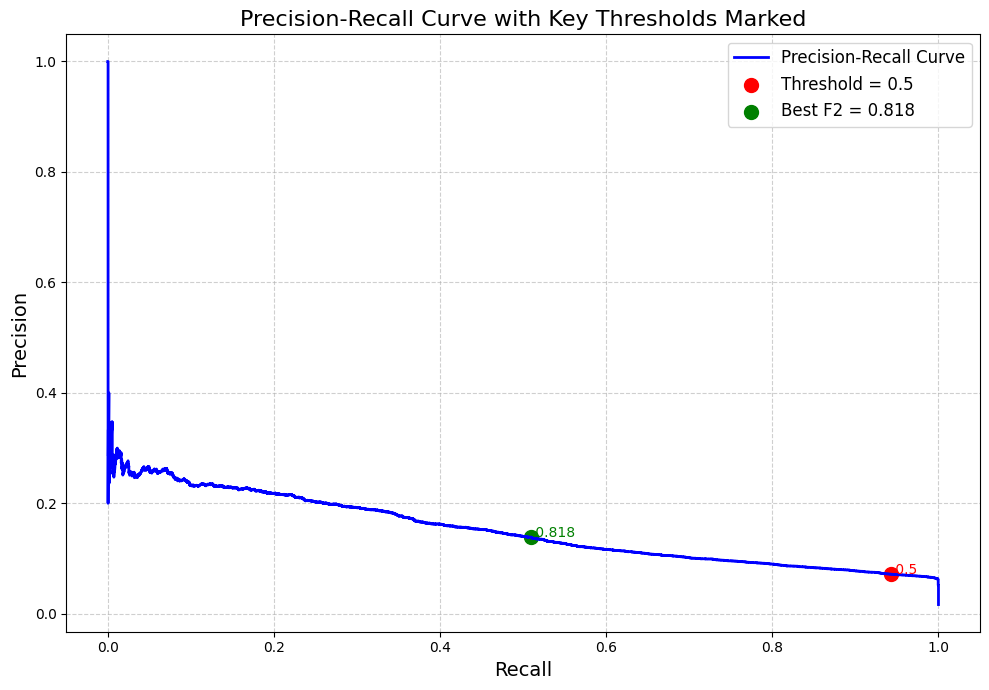

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# =============================================
# Compute PR Curve
# =============================================
prec, rec, thresh = precision_recall_curve(y_test, probs)

# ---------------------------------------------
# Points for thresholds
# ---------------------------------------------
# Default threshold = 0.5
p_05 = prec[np.argmin(np.abs(thresh - 0.5))]
r_05 = rec[np.argmin(np.abs(thresh - 0.5))]

# F2 threshold
p_f2 = prec[best_idx]
r_f2 = rec[best_idx]



# =============================================
# Plot
# =============================================
plt.figure(figsize=(10, 7))

# PR curve
plt.plot(rec, prec, label="Precision-Recall Curve", color="blue", linewidth=2)

# Mark Default (0.5)
plt.scatter(r_05, p_05, color="red", s=100, label="Threshold = 0.5")
plt.text(r_05, p_05, " 0.5", fontsize=10, color="red")

# Mark Best F2
plt.scatter(r_f2, p_f2, color="green", s=100, label=f"Best F2 = {best_thresh:.3f}")
plt.text(r_f2, p_f2, f" {best_thresh:.3f}", fontsize=10, color="green")



# Labels and style
plt.title("Precision-Recall Curve with Key Thresholds Marked", fontsize=16)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


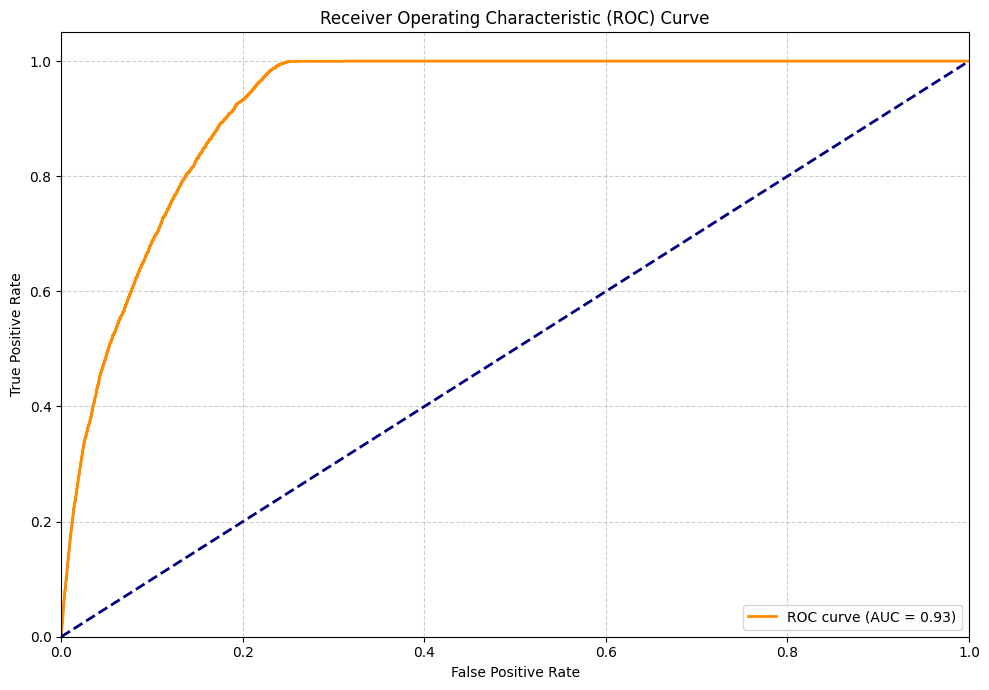

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

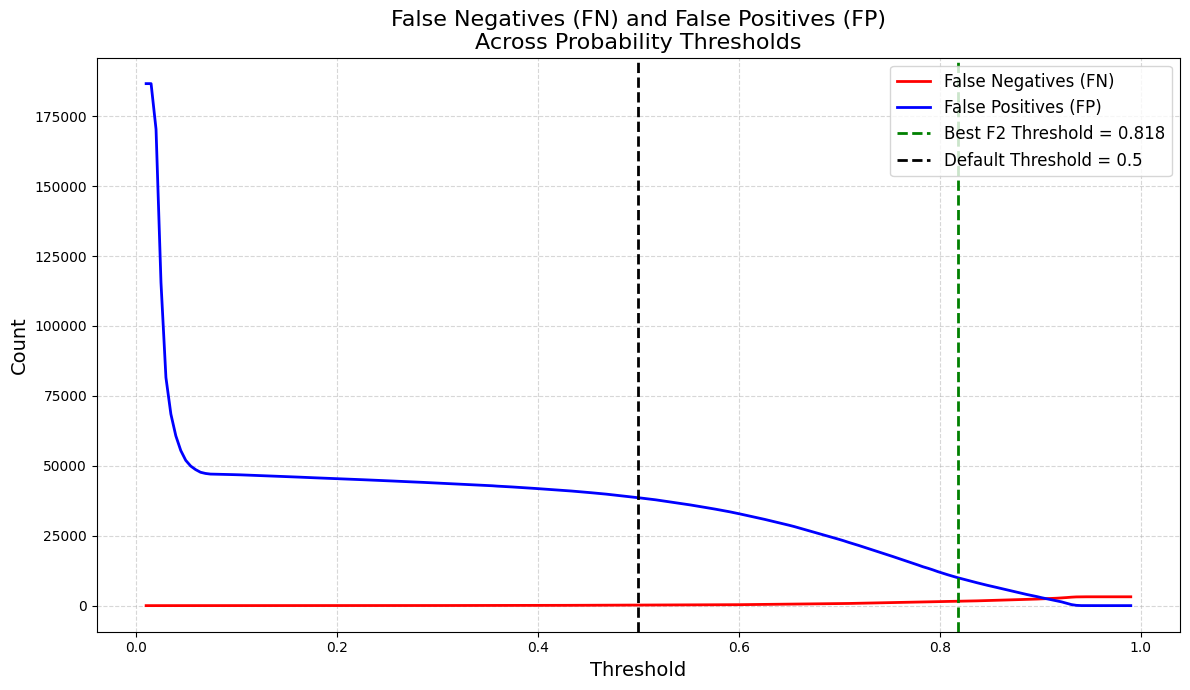

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------
# Sweep thresholds
# ------------------------------------------------------
thresholds = np.linspace(0.01, 0.99, 200)

FN_list = []
FP_list = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    FN_list.append(fn)
    FP_list.append(fp)

# ------------------------------------------------------
# Plot FN and FP vs threshold
# ------------------------------------------------------
plt.figure(figsize=(12, 7))

plt.plot(thresholds, FN_list, label="False Negatives (FN)", color="red", linewidth=2)
plt.plot(thresholds, FP_list, label="False Positives (FP)", color="blue", linewidth=2)



# Highlight F2 threshold
plt.axvline(best_thresh, color="green", linestyle="--", linewidth=2,
            label=f"Best F2 Threshold = {best_thresh:.3f}")

# Highlight default 0.5 threshold
plt.axvline(0.5, color="black", linestyle="--", linewidth=2,
            label="Default Threshold = 0.5")

plt.title("False Negatives (FN) and False Positives (FP)\nAcross Probability Thresholds", fontsize=16)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


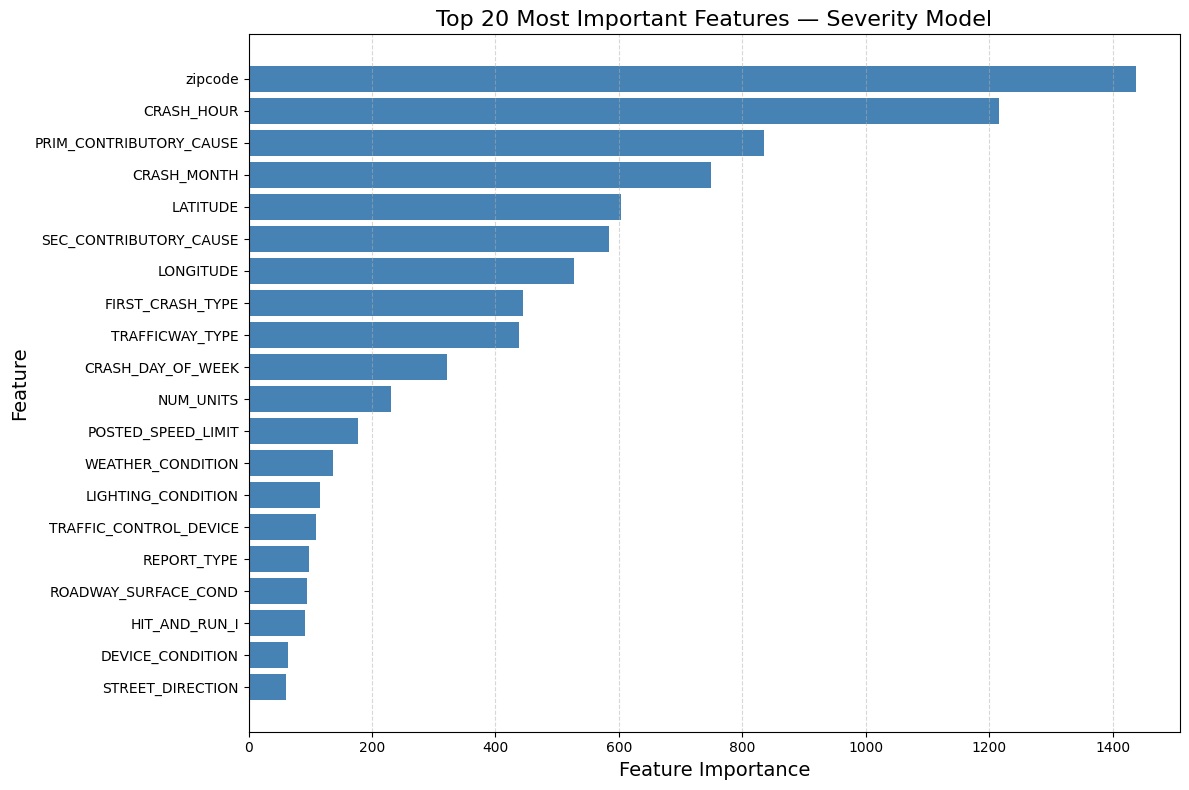

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Extract feature importances from the fitted LGBM model
importance_df = pd.DataFrame({
    "feature": lgbm.feature_name_,
    "importance": lgbm.feature_importances_
})

# 2) Sort by importance
importance_df = importance_df.sort_values("importance", ascending=False)

# 3) Take top 20
topN = 20
top_features = importance_df.head(topN).iloc[::-1]  # reverse for barh

# 4) Plot
plt.figure(figsize=(12, 8))
plt.barh(top_features["feature"], top_features["importance"], color="steelblue")

# Titles & labels
plt.title(f"Top {topN} Most Important Features — Severity Model", fontsize=16)
plt.xlabel("Feature Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)

# Grid for better readability
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


**verify whether the contributory cause columns introduced data leakage, retrained the model by  removing them.**

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import numpy as np
import pandas as pd

# ================================================================
# 0. ORIGINAL TRAIN/TEST SPLIT (same for all experiments)
# ================================================================
X = df_model.copy()
y_copy = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_copy,
    test_size=0.2,
    random_state=42,
    stratify=y_copy
)

print("Original train severe rate:", y_train.mean())
print("Original test severe rate:", y_test.mean())
print("------------------------------------------------------")


# ================================================================
# FUNCTION TO RUN EXPERIMENT WITH CLEAN FEATURES + RESAMPLING
# ================================================================
def run_clean_experiment(target_ratio):
    global lgbm_clean

    print(f"\n==================== Testing CLEAN Model @ {target_ratio*100:.0f}% Resampling ====================")

    # ---------------------------------------------
    # 1. RESAMPLE MINORITY CLASS
    # ---------------------------------------------
    train_df = X_train.copy()
    train_df["label"] = y_train

    minor = train_df[train_df["label"] == 1]
    major = train_df[train_df["label"] == 0]

    target_minority_size = int(target_ratio * len(major))

    minor_up = resample(
        minor, replace=True, n_samples=target_minority_size, random_state=42
    )

    train_balanced = pd.concat([major, minor_up]).sample(frac=1, random_state=42)

    X_train_bal = train_balanced.drop("label", axis=1)
    y_train_bal = train_balanced["label"]

    print("Balanced severe rate:", y_train_bal.mean())

    # ---------------------------------------------
    # 2. REMOVE CONTRIBUTORY CAUSE COLUMNS
    # ---------------------------------------------
    cols_to_remove = ["PRIM_CONTRIBUTORY_CAUSE", "SEC_CONTRIBUTORY_CAUSE"]

    X_train_clean = X_train_bal.drop(columns=[c for c in cols_to_remove if c in X_train_bal.columns])
    X_test_clean  = X_test.drop(columns=[c for c in cols_to_remove if c in X_test.columns])

    # ---------------------------------------------
    # 3. CONVERT CATEGORICALS
    # ---------------------------------------------
    categorical_clean = [c for c in categorical_cols_final if c in X_train_clean.columns]

    for col in categorical_clean:
        X_train_clean[col] = X_train_clean[col].astype("category")
        X_test_clean[col]  = X_test_clean[col].astype("category")

    # ---------------------------------------------
    # 4. TRAIN LIGHTGBM
    # ---------------------------------------------
    lgbm_clean = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=127,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight={0:1, 1:5},
        n_jobs=-1
    )

    lgbm_clean.fit(
        X_train_clean, y_train_bal,
        eval_set=[(X_test_clean, y_test)],
        eval_metric="auc",
        categorical_feature=categorical_clean,
        callbacks=[early_stopping(stopping_rounds=100)]
    )

    # ---------------------------------------------
    # 5. RECOMPUTE BEST F2 THRESHOLD
    # ---------------------------------------------
    probs_clean = lgbm_clean.predict_proba(X_test_clean)[:, 1]

    prec, rec, thresh = precision_recall_curve(y_test, probs_clean)
    beta = 2.0
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)

    best_idx = np.nanargmax(f2)
    best_thresh_clean = thresh[best_idx] if best_idx < len(thresh) else 0.5

    pred_clean = (probs_clean >= best_thresh_clean).astype(int)

    # ---------------------------------------------
    # 6. PRINT RESULTS
    # ---------------------------------------------
    print(f"Best F2 Threshold = {best_thresh_clean:.3f}")
    print(classification_report(y_test, pred_clean, digits=3))
    cm = confusion_matrix(y_test, pred_clean)
    print("Confusion Matrix:\n", cm)

    # return results for plotting/summary
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]
    TN = cm[0][0]

    return {
        "ratio": target_ratio,
        "threshold": best_thresh_clean,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "TN": TN,
        "precision": classification_report(y_test, pred_clean, output_dict=True)["1"]["precision"],
        "recall": classification_report(y_test, pred_clean, output_dict=True)["1"]["recall"],
        "f2": f2[best_idx]
    }


# ================================================================
# RUN EXPERIMENTS FOR MULTIPLE RATIOS
# ================================================================
ratios = [0.20, 0.25, 0.30]
results_clean = []

for r in ratios:
    res = run_clean_experiment(r)
    results_clean.append(res)


# ================================================================
# PRINT SUMMARY
# ================================================================
print("\n===================== CLEAN MODEL SUMMARY =====================")
for r in results_clean:
    print(f"{int(r['ratio']*100)}%: FP={r['FP']}, FN={r['FN']}, Precision={r['precision']:.3f}, Recall={r['recall']:.3f}, F2={r['f2']:.3f}, Threshold={r['threshold']:.3f}")


AttributeError: 'int' object has no attribute 'copy'

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------
# Your CLEAN MODEL results (without cause columns)
# ---------------------------------------
ratios = [20, 25, 30]   # in percent

FP_clean = [12578, 13597, 13092]
FN_clean = [1408, 1337, 1357]

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(10,6))

# FP line
plt.plot(ratios, FP_clean, marker='o', linewidth=3, label="False Positives (FP) - Clean Model")
for x, y in zip(ratios, FP_clean):
    plt.text(x, y-700, str(y), ha='center', fontsize=12, color='blue')  # label above point

# FN line
plt.plot(ratios, FN_clean, marker='o', linewidth=3, label="False Negatives (FN) - Clean Model")
for x, y in zip(ratios, FN_clean):
    plt.text(x, y+200, str(y), ha='center', fontsize=12, color='orange')  # label below point

plt.title("FP & FN vs. Resampling Ratio (Without Contributory Cause Columns)", fontsize=16)
plt.xlabel("Minority Upsampling Ratio (%)", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(ratios)
plt.legend(fontsize=12)

plt.show()


In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Results WITH contributory cause columns
# ---------------------------------------------------------
ratios = [20, 25, 30]     # in percent

FP_with = [10809, 9979, 12815]
FN_with = [1477, 1549, 1321]

# ---------------------------------------------------------
# Results WITHOUT contributory cause columns
# ---------------------------------------------------------
FP_clean = [12578, 13597, 13092]
FN_clean = [1408, 1337, 1357]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(12,7))

# ===== FP LINES =====
plt.plot(ratios, FP_with, marker='o', linewidth=3, color='blue', label="FP (With Cause Columns)")
plt.plot(ratios, FP_clean, marker='o', linewidth=3, color='cyan', label="FP (Without Cause Columns)")

# Add labels for FP
for x, y in zip(ratios, FP_with):
    plt.text(x, y-800, str(y), ha='center', fontsize=11, color='blue')
for x, y in zip(ratios, FP_clean):
    plt.text(x, y+270, str(y), ha='center', fontsize=11, color='cyan')

# ===== FN LINES =====
plt.plot(ratios, FN_with, marker='o', linewidth=3, color='red', label="FN (With Cause Columns)")
plt.plot(ratios, FN_clean, marker='o', linewidth=3, color='orange', label="FN (Without Cause Columns)")

# Add labels for FN
for x, y in zip(ratios, FN_with):
    plt.text(x, y+200, str(y), ha='center', fontsize=11, color='red')
for x, y in zip(ratios, FN_clean):
    plt.text(x, y-600, str(y), ha='center', fontsize=11, color='orange')

# ---------------------------------------------------------
# Graph formatting
# ---------------------------------------------------------
plt.title("FP & FN vs Resampling Ratio\nWith vs Without Contributory Cause Columns", fontsize=17)
plt.xlabel("Minority Upsampling Ratio (%)", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(ratios)
plt.legend(fontsize=12)

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Extract feature importances from CLEAN model (without cause columns)
importance_clean_df = pd.DataFrame({
    "feature": lgbm_clean.feature_name_,
    "importance": lgbm_clean.feature_importances_
})

# 2) Sort by importance
importance_clean_df = importance_clean_df.sort_values("importance", ascending=False)

# 3) Take top 20
topN = 20
top_features_clean = importance_clean_df.head(topN).iloc[::-1]  # reverse for barh

# 4) Plot
plt.figure(figsize=(12, 8))
plt.barh(top_features_clean["feature"], top_features_clean["importance"], color="darkorange")

# Titles & labels
plt.title(f"Top {topN} Most Important Features — Clean Model (Without Cause Columns)", fontsize=16)
plt.xlabel("Feature Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)

# Grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
